# Decision Trees and Ensemble Methods

## Learning Objectives

1. Understand how Decision Trees perform classification
2. Train and visualize a Decision Tree classifier
3. Explain the role of pruning in preventing overfitting
4. Analyze instability in feature selection and tree structure
5. Improve classification performance using ensemble methods
6. Compare Decision Trees, Random Forests, and AdaBoost classifiers

## 1. Imports and Dataset

Run the following cell to import libraries and dataset. The dataset includes 30 features, related to the characteristics of a tumor tissue, and the corresponding classification of the tumor as benign or malignant:
* X = dataframe of input features
* y = class (0 = benign; 1 = tumor)
* features = the list of feature names
* class_names = the name of the two classes

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Load biomedical dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

features = X.columns
class_names = ['benign', 'tumor']
print('Feature names:', features)
print('Number of samples:', X.shape[0])
print('Number of tumor samples:', np.sum(y == 1))

Feature names: Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')
Number of samples: 569
Number of tumor samples: 357


## 2. Train/Test Split
* Split the dataset into train and test (30%)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 398
Testing samples: 171


## 3. Complete Decision Tree

* Train a model of the class DecisionTreeClassifier without any pruning
* Evaluate its performance in the testing and training set
* Use the function plot_tree to visualize the  decision tree. Usefull parameters to improve the quality of the figures are: filled, fontsize, feature_names, max_depth, and class_names. Another suggestion is to manually define the size of the figure in the command plt.figure (example: plt.*figure(figsize=(20, 10))*)

Training accuracy: 1.0
Testing accuracy: 0.9181286549707602


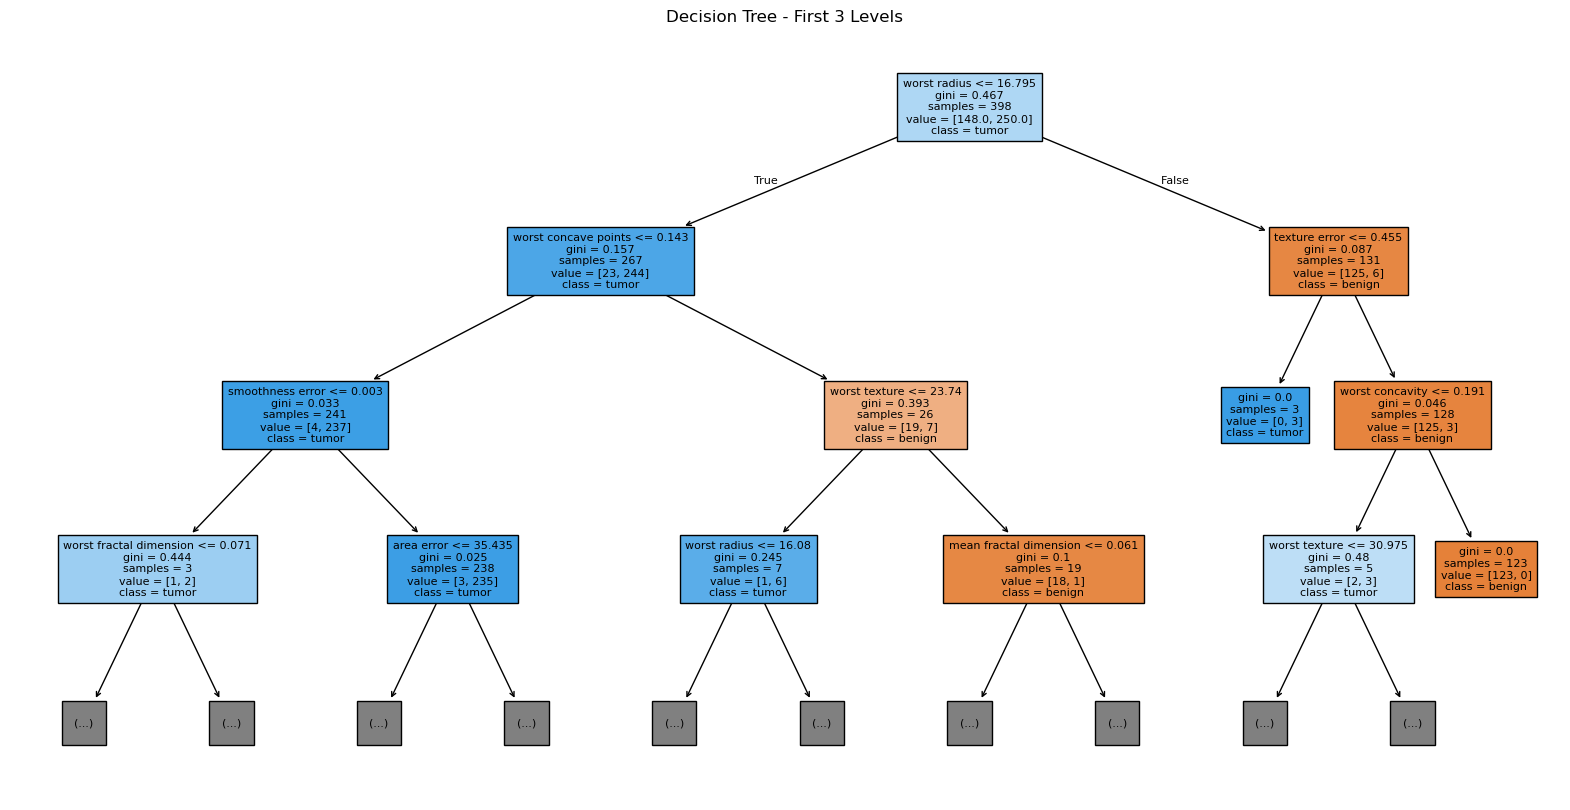

In [26]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred_train = tree.predict(X_train)
y_pred_test = tree.predict(X_test)

print("Training accuracy:", accuracy_score(y_train, y_pred_train))
print("Testing accuracy:", accuracy_score(y_test, y_pred_test))

plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=features,
    class_names=class_names,
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("Decision Tree - First 3 Levels")
plt.show()

## 4. Cost-Complexity Pruning

The hyperparameter `ccp_alpha` penalizes large trees.

The pruning objective is:

$$
R_\alpha(T) = R(T) + \alpha |T|
$$

where:

- R(T): classification error
- |T|: number of terminal nodes
- alpha: pruning strength

Larger values of `ccp_alpha` produce simpler trees.

* Use cross-validation to train a regularized decision tree. Test the following alpha values: \[0.0, 0.001, 0.005, 0.01, 0.02\]
* Report accuracy in the training and testing set
* Compare the regularized tree with the one defined before

In [27]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
param_grid = {
    "ccp_alpha": [0.0, 0.001, 0.005, 0.01, 0.02]
}
dt_cv = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=dt_cv,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)
grid_search.fit(X_train, y_train)
print("Best cross-validation accuracy:", grid_search.best_score_)
print("Best pruning parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred_train_pruned = best_model.predict(X_train)
y_pred_test_pruned = best_model.predict(X_test)
print("Training accuracy:", accuracy_score(y_train, y_pred_train_pruned))
print("Testing accuracy:", accuracy_score(y_test, y_pred_test_pruned))

Best cross-validation accuracy: 0.9421835443037974
Best pruning parameters: {'ccp_alpha': 0.005}
Training accuracy: 0.9849246231155779
Testing accuracy: 0.9298245614035088


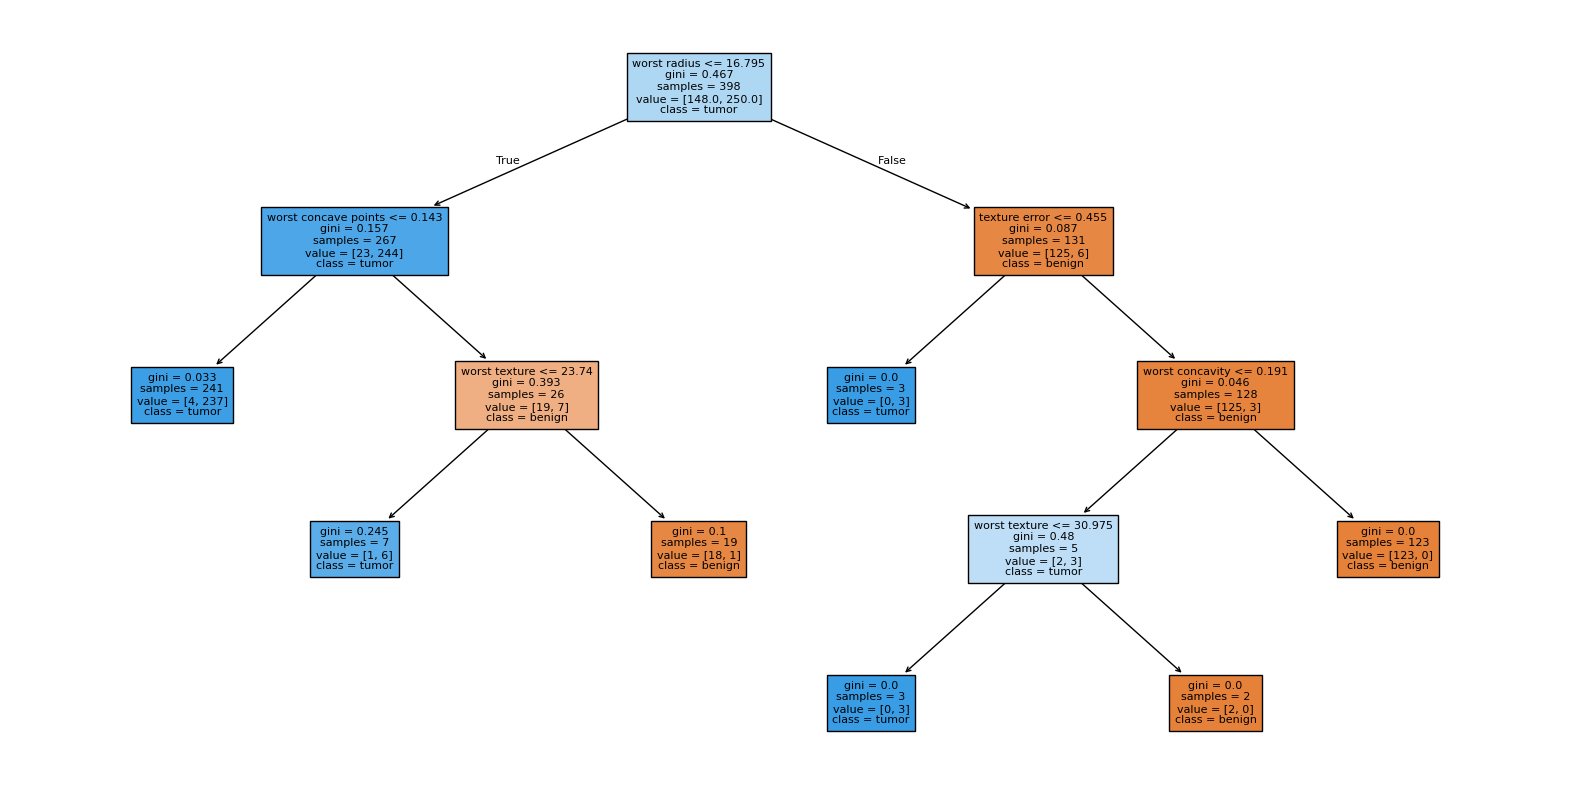

In [28]:
plt.figure(figsize=(20, 10))
plot_tree(
    best_model,
    feature_names=features,
    class_names=class_names,
    filled=True,
    fontsize=8
)
plt.show()

## 5. Instability of Decision Trees

Decision Trees are unstable learners.

Small changes in the training data may produce different tree structures and feature importances.

* Train two Decision Trees with parameter max_depth equal to 3 using different random splits of training and testing sets
* Plot the importance of the features (attribute .feature_importances_) for the two trees

Text(0.5, 1.0, 'Tree2')

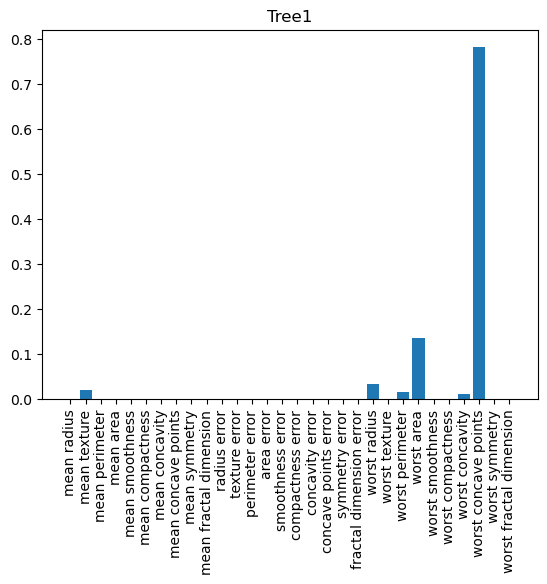

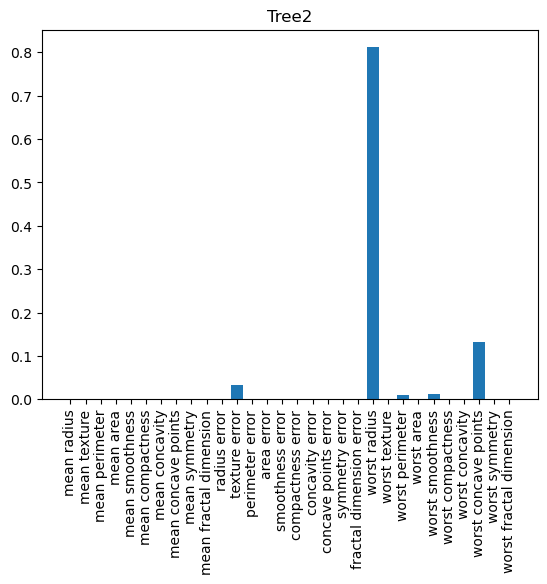

In [29]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=1,
    stratify=y
)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=10,
    stratify=y
)

tree1 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree2 = DecisionTreeClassifier(max_depth=3, random_state=42)
tree1.fit(X_train1, y_train1)
tree2.fit(X_train2, y_train2)

f = plt.figure()
ax1 = f.add_subplot(1,1,1)
ax1.bar(np.arange(len(features)), tree1.feature_importances_)
ax1.set_xticks(np.arange(len(features)))
ax1.set_xticklabels(features, rotation=90)
plt.title('Tree1')

f = plt.figure()
ax1 = f.add_subplot(1,1,1)
ax1.bar(np.arange(len(features)), tree2.feature_importances_)
ax1.set_xticks(np.arange(len(features)))
ax1.set_xticklabels(features, rotation=90)
plt.title('Tree2')

## 6. Random Forests

Random Forests train many Decision Trees using:

- Bootstrap sampling
- Random feature subsets

For classification, the final prediction is usually obtained by majority vote.

The main idea is that combining many unstable trees creates a more stable and accurate classifier.

* Train a random forest classifier (class RandomForestClassifier) using the following parameters:
  * n_estimators = 100
  * max_depth = 5
* Report the accuracy in the training and testing set
* Repeat the previous analysis about the stability of features'importance in two separate training set

In [30]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf = rf.predict(X_test)
print("Training accuracy:", accuracy_score(y_train, y_pred_train_rf))
print("Testing accuracy:", accuracy_score(y_test, y_pred_test_rf))

Training accuracy: 0.992462311557789
Testing accuracy: 0.9415204678362573


Text(0.5, 1.0, 'Tree2')

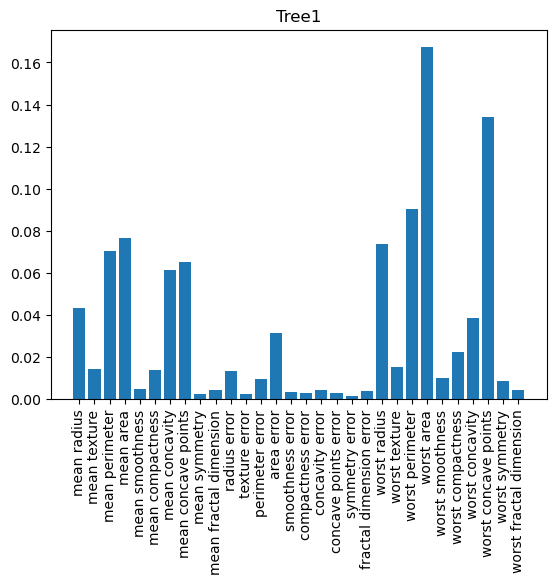

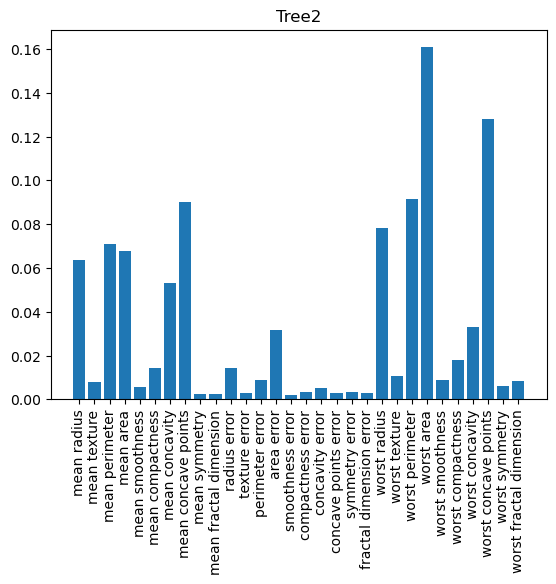

In [31]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=1,
    stratify=y
)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=10,
    stratify=y
)

tree1 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
tree2 = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
tree1.fit(X_train1, y_train1)
tree2.fit(X_train2, y_train2)

f = plt.figure()
ax1 = f.add_subplot(1,1,1)
ax1.bar(np.arange(len(features)), tree1.feature_importances_)
ax1.set_xticks(np.arange(len(features)))
ax1.set_xticklabels(features, rotation=90)
plt.title('Tree1')

f = plt.figure()
ax1 = f.add_subplot(1,1,1)
ax1.bar(np.arange(len(features)), tree2.feature_importances_)
ax1.set_xticks(np.arange(len(features)))
ax1.set_xticklabels(features, rotation=90)
plt.title('Tree2')

Each tree in the Random Forest has its own feature importance vector.

For each feature, we compute:

$$
SE_j = \frac{s_j}{\sqrt{M}}
$$

where:

- s_j is the standard deviation of feature importance across trees,
- M is the number of trees.

* Compute the average and the standard error of the feature importance. The trees are available from the attribute .estimators_ of the random forest object
* Plot the average feature importance with the corresponding standard error

Text(0.5, 1.0, 'Tree2')

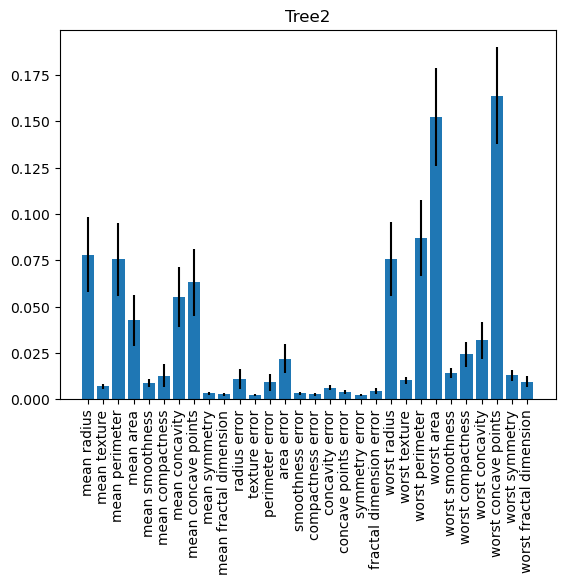

In [32]:
rf_tree_importances = np.array([
    estimator.feature_importances_
    for estimator in rf.estimators_
])

rf_mean_importance = rf_tree_importances.mean(axis=0)
rf_std_importance = rf_tree_importances.std(axis=0, ddof=1)
rf_se_importance = rf_std_importance / np.sqrt(rf_tree_importances.shape[0])

f = plt.figure()
ax1 = f.add_subplot(1,1,1)
ax1.bar(np.arange(len(features)), rf_mean_importance, yerr= rf_se_importance )
ax1.set_xticks(np.arange(len(features)))
ax1.set_xticklabels(features, rotation=90)
plt.title('Tree2')

## 17. Adaptive Boosting

AdaBoost sequentially trains weak learners, with the hey idea that misclassified samples receive larger weights, and consequenlty new classifiers focus more strongly on difficult cases. The final classifier combines weighted predictions from all weak learners.

* Train an Adaptive Boosting classifier (class AdaBoost) using the following parameters:
  * n_estimators = 100
  * learning_rate = 0.5
* Report the accuracy in the training and testing set

In [20]:
ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)
ada.fit(X_train, y_train)
y_pred_train_rf = ada.predict(X_train)
y_pred_test_rf = ada.predict(X_test)
print("Training accuracy:", accuracy_score(y_train, y_pred_train_rf))
print("Testing accuracy:", accuracy_score(y_test, y_pred_test_rf))

Training accuracy: 1.0
Testing accuracy: 0.9532163742690059
